In [1]:

import sys
import itertools
from tqdm.auto import tqdm
import pathlib
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score

import datasets
from contextlib import nullcontext
import torch
from torch import nn
from transformers import (
    Trainer,
    TrainingArguments,
    LlamaTokenizer,
    LlamaForSequenceClassification,
    TrainerCallback,
    default_data_collator,
)
from peft import (
    get_peft_model,
    LoraConfig,
    TaskType,
    prepare_model_for_int8_training,
)


sys.path.append("../src")
sys.path.append("../config")
from utils import number_split, create_mix


from process_HateSpeech import load_HateSpeech_dynGen, load_HateSpeech_wsf
from process_SHAC import load_process_SHAC

from sampling_numbers import HateSpeech_DICT, SHAC_DICT

import warnings

warnings.simplefilter("ignore")


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [117]:
df_dynGen = load_HateSpeech_dynGen()
df_wsf = load_HateSpeech_wsf()

In [3]:
df_shac = load_process_SHAC(replaceNA="all")

df_shac_uw = df_shac.query("location == 'uw'").reset_index(drop=True)
df_shac_mimic = df_shac.query("location == 'mimic'").reset_index(drop=True)


In [5]:
print(df_dynGen['label_binary'].sum()/len(df_dynGen))
print(df_wsf['label_binary'].sum()/len(df_wsf))

0.5389607233132413
0.1117443707371765


In [ ]:
print(df_shac_uw['Drug'].sum()/len(df_shac_uw))
print(df_shac_mimic['Drug'].sum()/len(df_shac_mimic))

# Sampling

In [ ]:
## Hate Speech

df0 = df_dynGen
df1 = df_wsf
df_split_label = "label_binary"

p_pos_train_z0_ls = np.arange(0, 1, 0.1) # probability of training set examples drawn from site/domain z0 being positive
p_pos_train_z1_ls = np.arange(0, 1, 0.1) # probability of test set examples drawn from site/domain z1 being positive
p_mix_z1_ls     = np.arange(0.1, 1, 0.1) 
n_test = 1000



## SHAC

# df_split_label = "Drug"

# df0 = df_shac_uw
# df1 = df_shac_mimic
# p_pos_train_z0_ls = np.arange(0, 1, 0.1)
# p_pos_train_z1_ls = np.arange(0, 1, 0.1)
# p_mix_z1_ls = np.arange(0, 1, 0.05)

# n_test = 200

##### Split

train_test_ratio = 4


numvals = 1023
base = 1.1
alpha_test_ls = np.power(base, np.arange(numvals)) / np.power(base, numvals // 2)



valid_full_settings = []
for combination in itertools.product(
    p_pos_train_z0_ls, p_pos_train_z1_ls, p_mix_z1_ls, alpha_test_ls
):
    number_setting = number_split(
        p_pos_train_z0=combination[0],
        p_pos_train_z1=combination[1],
        p_mix_z1=combination[2],
        alpha_test=combination[3],
        train_test_ratio=train_test_ratio,
        n_test=n_test,
        verbose=False,
    )

    
    
        
    if number_setting is not None:
        if np.all([number_setting[k] >= 10 for k in list(number_setting.keys())[:-1]]):
            valid_full_settings.append(number_setting)





valid_n_full_settings = []

_n_setting = 0
for c in tqdm(valid_full_settings):
        c = c.copy()
        # create train/test split according to stats
        dfs = create_mix(df0=df0, df1=df1, target=df_split_label, setting=c, sample=False, 
                         seed=222
                        )

        if dfs is None:
            continue
            
        # if round(c['mix_param_dict']['alpha_train'], 4) not in [1, 1.5, 0.6667, 2, 0.5, 3, 0.3333, 4, 0.25, 6, 0.1667]:
        #         continue
        if round(c['mix_param_dict']['alpha_train'], 4) not in [1, 2, 0.5, 4, 0.25, 6, 0.1667]:
                continue
                
        _n_setting += 1
        
        if _n_setting % 25 != 0:
            continue
            
        valid_n_full_settings.append(c)

  0%|          | 0/30119 [00:00<?, ?it/s]

In [26]:
tmp_ALL_df = [x['mix_param_dict'] for x in valid_full_settings]

df_ALL = pd.DataFrame(tmp_ALL_df)

df_ALL['alpha_train'] = df_ALL['alpha_train'].round(4)

In [ ]:
g = sns.FacetGrid(df_ALL, col="alpha_train",col_wrap=3)
# g.map(sns.lineplot, "alpha_test", "p_pos_train_z1")
g.map(sns.histplot, "alpha_test")

plt.xscale('log')

In [35]:
tmp_df = [x['mix_param_dict'] for x in valid_n_full_settings]

df = pd.DataFrame(tmp_df)

df['alpha_train'] = df['alpha_train'].round(4)
df['y'] = 1

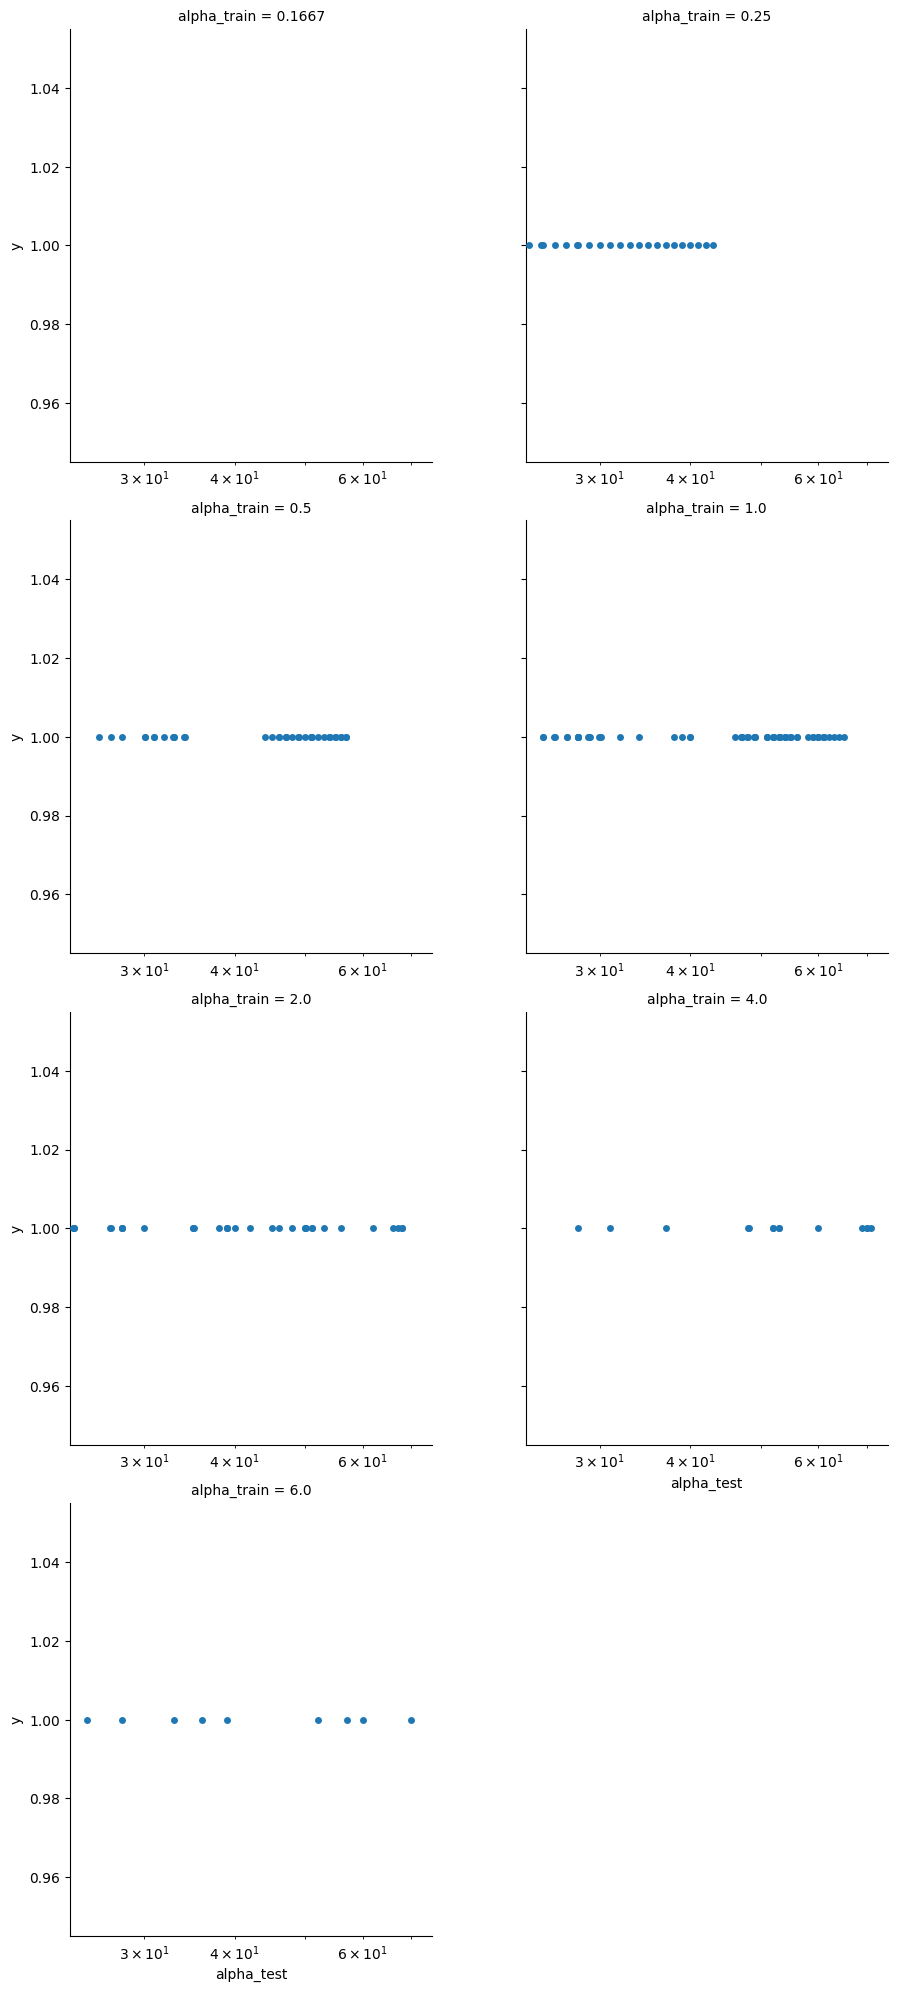

In [41]:


g = sns.FacetGrid(df, col="alpha_train",col_wrap=2, height=5)
g.map(sns.stripplot, "alpha_test", "y")
# g.map(sns.histplot, "alpha_test")

plt.xscale('log')

In [12]:
df

,p_pos_train_z0,p_pos_train_z1,p_pos_train,p_pos_test,p_mix_z0,p_mix_z1,alpha_train,alpha_test,p_pos_test_z0,p_pos_test_z1,C_y,C_z
0,0.1,0.1,0.1,0.1,0.9,0.1,1.0,1.464100,0.095565,0.139916,0.1,0.1
1,0.1,0.1,0.1,0.1,0.9,0.1,1.0,2.357948,0.088044,0.207603,0.1,0.1
2,0.1,0.1,0.1,0.1,0.9,0.1,1.0,3.797498,0.078140,0.296738,0.1,0.1
3,0.1,0.1,0.1,0.1,0.9,0.1,1.0,6.115909,0.066155,0.404601,0.1,0.1
4,0.1,0.1,0.1,0.1,0.9,0.1,1.0,9.849733,0.053051,0.522540,0.1,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...
2019,0.9,0.9,0.9,0.9,0.9,0.1,1.0,0.197845,0.978490,0.193589,0.9,0.1
2020,0.9,0.9,0.9,0.9,0.9,0.1,1.0,0.318631,0.965807,0.307736,0.9,0.1
2021,0.9,0.9,0.9,0.9,0.9,0.1,1.0,0.513158,0.946058,0.485477,0.9,0.1
2022,0.9,0.9,0.9,0.9,0.9,0.1,1.0,0.826446,0.915896,0.756939,0.9,0.1


# Simple Sampling no Alpha Train...

In [418]:
####### MODIFY!!!! Sample By Train Group!!

## Hate Speech

df0 = df_dynGen
df1 = df_wsf
df_split_label = "label_binary"

p_pos_train_z0_ls = np.arange(0, 1, 0.1) # probability of training set examples drawn from site/domain z0 being positive
p_pos_train_z1_ls = np.arange(0, 1, 0.1) # probability of test set examples drawn from site/domain z1 being positive
p_mix_z1_ls     = np.arange(0.1, 1, 0.1) 
n_test = 200

train_test_ratio = 4


# numvals = 1023
# base = 1.1
# alpha_test_ls = np.power(base, np.arange(numvals)) / np.power(base, numvals // 2)

# alpha_test_ls = np.float_power(10, np.arange(-2,2,1e-3))
alpha_test_ls = np.float_power(10, np.linspace(start=-2, stop=2, num=30))

In [419]:
c = HateSpeech_DICT["c_n1000_1874"]
txt_col = 'text'
dfs_used = create_mix(df0=df0, df1=df1, target=df_split_label, setting=c, sample=False, 
                # seed=random.randint(0,1000),
                seed=222
                )

assert dfs_used is not None

df0 = df0[~df0[txt_col].isin(dfs_used['train'][txt_col])].reset_index(drop=True)
df0 = df0[~df0[txt_col].isin(dfs_used['test'][txt_col])].reset_index(drop=True)


df1 = df1[~df1[txt_col].isin(dfs_used['train'][txt_col])].reset_index(drop=True)
df1 = df1[~df1[txt_col].isin(dfs_used['test'][txt_col])].reset_index(drop=True)



In [420]:


valid_full_settings = []
for combination in itertools.product(
    p_pos_train_z0_ls, p_pos_train_z1_ls, p_mix_z1_ls, alpha_test_ls
):
    number_setting = number_split(
        p_pos_train_z0=combination[0],
        p_pos_train_z1=combination[1],
        p_mix_z1=combination[2],
        alpha_test=combination[3],
        train_test_ratio=train_test_ratio,
        n_test=n_test,
        verbose=False,
    )

    
    
        
    if number_setting is not None:
        if np.all([number_setting[k] >= 10 for k in list(number_setting.keys())[:-1]]):
            valid_full_settings.append(number_setting)



In [421]:
tmp_df = [x['mix_param_dict'] for x in valid_full_settings]

tmp_df = pd.DataFrame(tmp_df)

tmp_df['alpha_train'] = tmp_df['alpha_train'].round(4)
tmp_df['C_y1'] = np.floor(tmp_df['C_y']*10)/10
tmp_df['combination'] = valid_full_settings


dfgrp = tmp_df.groupby(["C_y","C_y1"], as_index=False).size()

dfgrp = dfgrp.sort_values("size", ascending=False)

dfgrp = dfgrp.groupby("C_y1",as_index=False).head(1).iloc[:5,:]

tmp_df = tmp_df[tmp_df['C_y'].isin(dfgrp['C_y'])]

dfgrp = tmp_df.groupby(["p_mix_z1"], as_index=False).size()
dfgrp = dfgrp.sort_values("size", ascending=False).iloc[:5,:]

tmp_df = tmp_df[tmp_df['p_mix_z1'].isin(dfgrp['p_mix_z1'])]

_sizegrp = tmp_df.groupby('C_y', as_index=False).size().sort_values('size', ascending=True)
cy_notsample = _sizegrp.iloc[:2,:]['C_y'].tolist()

grouped = tmp_df.groupby(['C_y','p_mix_z1'])

_tmp = []
for g,_dt in grouped:
    _dt = _dt.sort_values("alpha_test")
    _d_len = len(_dt.sort_values("alpha_test"))
    
    if g[0] not in cy_notsample:
        sampler = np.random.choice(_d_len, int(30/100 * _d_len), replace=False)
        _tmp.append(_dt.iloc[sampler,:])
    else:
        sampler = np.random.choice(_d_len, min(int((30 + 10)/100 * _d_len), _d_len), replace=False)
        _tmp.append(_dt.iloc[sampler,:])

tmp_df = pd.concat(_tmp)

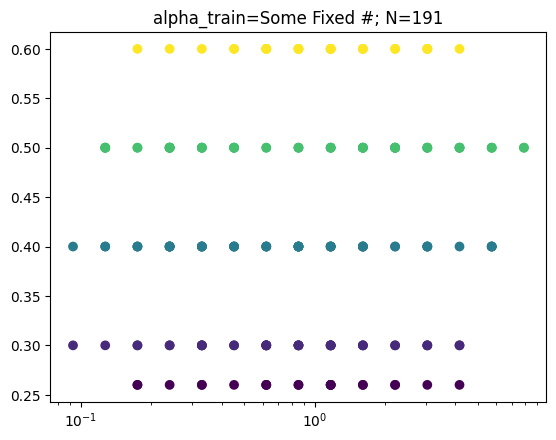

In [422]:

plt.figure()
plt.scatter(tmp_df['alpha_test'], tmp_df['C_y'], c=tmp_df['C_y'])
plt.title(f"alpha_train=Some Fixed #; N={len(tmp_df)}")
plt.xscale('log')
plt.show()

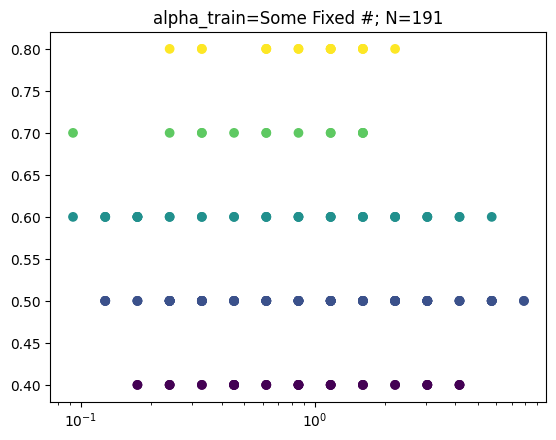

In [423]:

plt.figure()
plt.scatter(tmp_df['alpha_test'], tmp_df['p_mix_z1'], c=tmp_df['p_mix_z1'])
plt.title(f"alpha_train=Some Fixed #; N={len(tmp_df)}")
plt.xscale('log')
plt.show()

In [425]:
valid_full_settings = tmp_df['combination']

In [435]:

valid_n_full_settings = []

_n_setting = 0
for c in tqdm(valid_full_settings):
        c = c.copy()
        c['n_train'] = 0
        c['n_z0_pos_train'] = 1
        c['n_z0_neg_train'] = 1
        c['n_z1_pos_train'] = 1
        c['n_z1_neg_train'] = 1
        c['mix_param_dict']['p_pos_train_z0'] = 0
        c['mix_param_dict']['p_pos_train_z1'] = 0
        c['mix_param_dict']['p_pos_train'] = 0
        c['mix_param_dict']['alpha_train'] = 0
        
        # create train/test split according to stats
        dfs = create_mix(df0=df0, df1=df1, target=df_split_label, setting=c, sample=False, 
                         seed=222
                        )

        if dfs is None:
            continue
            
       
            
        valid_n_full_settings.append(c)

  0%|          | 0/191 [00:00<?, ?it/s]

In [439]:
df = [x['mix_param_dict'] for x in valid_n_full_settings]

df = pd.DataFrame(df)


In [440]:
df

,p_pos_train_z0,p_pos_train_z1,p_pos_train,p_pos_test,p_mix_z0,p_mix_z1,alpha_train,alpha_test,p_pos_test_z0,p_pos_test_z1,C_y,C_z
0,0,0,0,0.26,0.6,0.4,0,1.172102,0.243254,0.285119,0.26,0.4
1,0,0,0,0.26,0.6,0.4,0,3.039195,0.143197,0.435204,0.26,0.4
2,0,0,0,0.26,0.6,0.4,0,2.212216,0.175098,0.387354,0.26,0.4
3,0,0,0,0.26,0.6,0.4,0,0.853168,0.276223,0.235665,0.26,0.4
4,0,0,0,0.26,0.6,0.4,0,4.175319,0.114531,0.478203,0.26,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...
110,0,0,0,0.60,0.6,0.4,0,0.239503,0.862315,0.206527,0.60,0.4
111,0,0,0,0.60,0.6,0.4,0,0.174333,0.895879,0.156181,0.60,0.4
112,0,0,0,0.60,0.6,0.4,0,0.452035,0.768429,0.347357,0.60,0.4
113,0,0,0,0.60,0.5,0.5,0,0.452035,0.826426,0.373574,0.60,0.5


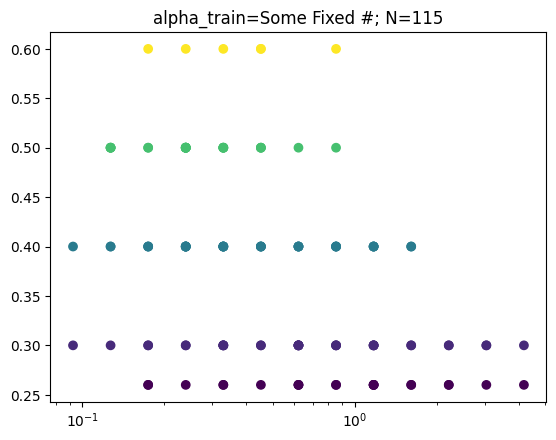

In [441]:

plt.figure()
plt.scatter(df['alpha_test'], df['C_y'], c=df['C_y'])
plt.title(f"alpha_train=Some Fixed #; N={len(df)}")
plt.xscale('log')
plt.show()

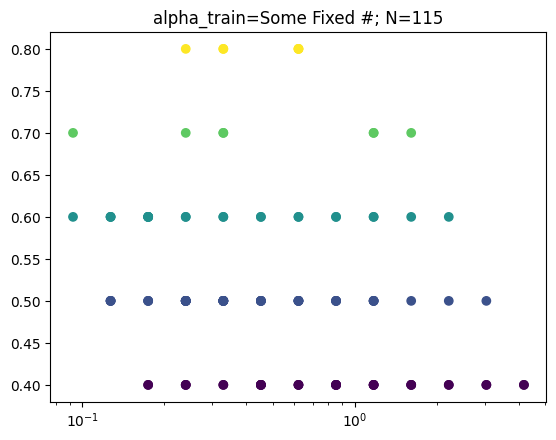

In [442]:

plt.figure()
plt.scatter(df['alpha_test'], df['p_mix_z1'], c=df['p_mix_z1'])
plt.title(f"alpha_train=Some Fixed #; N={len(df)}")
plt.xscale('log')
plt.show()

# Sample by Alpha Train Group

In [76]:
####### MODIFY!!!! Sample By Train Group!!

## Hate Speech

df0 = df_dynGen
df1 = df_wsf
df_split_label = "label_binary"

p_pos_train_z0_ls = np.arange(0, 1, 0.2) # probability of training set examples drawn from site/domain z0 being positive
p_pos_train_z1_ls = np.arange(0, 1, 0.2) # probability of test set examples drawn from site/domain z1 being positive
p_mix_z1_ls     = np.arange(0.1, 1, 0.1) 
n_test = 1000

train_test_ratio = 4


# numvals = 1023
# base = 1.1
# alpha_test_ls = np.power(base, np.arange(numvals)) / np.power(base, numvals // 2)

# alpha_test_ls = np.float_power(10, np.arange(-2,2,1e-3))
alpha_test_ls = np.float_power(10, np.linspace(start=-2, stop=2, num=30))

In [77]:
alpha_train_DICT = {}
for combination in itertools.product(
    p_pos_train_z0_ls, p_pos_train_z1_ls, p_mix_z1_ls
):
    alpha_train = combination[1]/combination[0]
    
    if alpha_train in [1, 2, 0.5, 4, 0.25]:
        if alpha_train not in alpha_train_DICT.keys():
            alpha_train_DICT[alpha_train] = []
        else:
            alpha_train_DICT[alpha_train].append(combination)


valid_full_settings = []
for alpha_train in alpha_train_DICT.keys():
    for combination in alpha_train_DICT[alpha_train]:
        for alpha_test in alpha_test_ls:
            number_setting = number_split(
                            p_pos_train_z0=combination[0],
                            p_pos_train_z1=combination[1],
                            p_mix_z1=combination[2],
                            alpha_test=alpha_test,
                            train_test_ratio=train_test_ratio,
                            n_test=n_test,
                            verbose=False,
            )

            if number_setting is not None:
                if np.all([number_setting[k] >= 10 for k in list(number_setting.keys())[:-1]]):
                    valid_full_settings.append(number_setting)

# valid_full_settings = []
# for combination in itertools.product(
#     p_pos_train_z0_ls, p_pos_train_z1_ls, p_mix_z1_ls, alpha_test_ls
# ):
#     number_setting = number_split(
#         p_pos_train_z0=combination[0],
#         p_pos_train_z1=combination[1],
#         p_mix_z1=combination[2],
#         alpha_test=combination[3],
#         train_test_ratio=train_test_ratio,
#         n_test=n_test,
#         verbose=False,
#     )

    
    
        
#     if number_setting is not None:
#         if np.all([number_setting[k] >= 10 for k in list(number_setting.keys())[:-1]]):
#             valid_full_settings.append(number_setting)




_tmp_valids = []

_n_setting = 0
for c in tqdm(valid_full_settings):
        c = c.copy()
        # create train/test split according to stats
        dfs = create_mix(df0=df0, df1=df1, target=df_split_label, setting=c, sample=False, 
                         seed=222
                        )

        if dfs is None:
            continue

        _tmp_valids.append(c)
        

  0%|          | 0/1140 [00:00<?, ?it/s]

In [78]:
tmp_df = [x['mix_param_dict'] for x in _tmp_valids]
tmp_df = pd.DataFrame(tmp_df)

tmp_df['alpha_train'] = tmp_df['alpha_train'].round(4)
tmp_df['C_y'] = round(tmp_df['C_y'],1)   
tmp_df['combination'] = _tmp_valids

_alpha_train_ls = tmp_df['alpha_train'].unique()
_dfs = []
for _alpha_train in _alpha_train_ls:
    if _alpha_train > 1:
        _df_0 = tmp_df[(tmp_df['alpha_train'] == _alpha_train)]
        _df_1 = tmp_df[(tmp_df['alpha_train'] == 1/_alpha_train)]
        
        _tt0 = _df_0.groupby('C_y', as_index=False).size().sort_values('size', ascending=False)
        _tt1 = _df_1.groupby('C_y', as_index=False).size().sort_values('size', ascending=False)
        
        _tt = _tt0.merge(_tt1, on='C_y', how="inner")

        _tt['size'] = _tt['size_x'] + _tt['size_y']

        cy_common = _tt.sort_values("size", ascending=False).loc[:,'C_y'].tolist()[:2]
        # cy_common = set(_df_0['C_y'].unique()).intersection(set(_df_1['C_y'].unique()))
        
        _dfs.append(_df_0[_df_0['C_y'].isin(cy_common)])
        _dfs.append(_df_1[_df_1['C_y'].isin(cy_common)])
        
        print(_alpha_train)
        print(cy_common)
    elif _alpha_train == 1:
        _df_0 = tmp_df[(tmp_df['alpha_train'] == _alpha_train)]
        
        _tt = _df_0.groupby('C_y', as_index=False).size().sort_values('size', ascending=False)
        
        cy_common = _tt.iloc[:2,0].tolist()
        
        
        _dfs.append(_df_0[_df_0['C_y'].isin(cy_common)])
        
        
        
df_combinations = pd.concat(_dfs)

2.0
[0.3, 0.2]
4.0
[0.4, 0.3]


In [84]:
len(df_combinations)

537

In [79]:
tmp_df = [x['mix_param_dict'] for x in df_combinations['combination']]

df = pd.DataFrame(tmp_df)

df['alpha_train'] = df['alpha_train'].round(4)
df['C_y'] = round(df['C_y'],1)

In [80]:
df['C_y'].unique()

array([0.2, 0.4, 0.3])

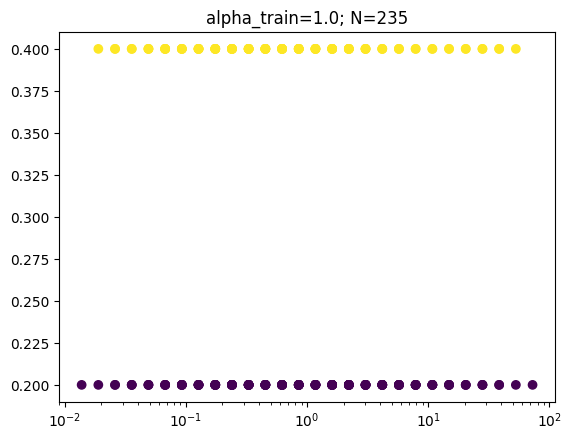

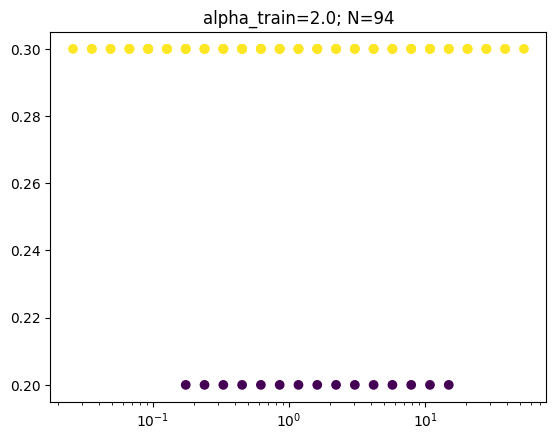

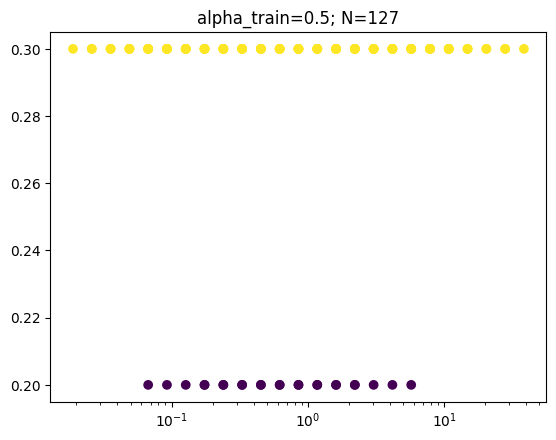

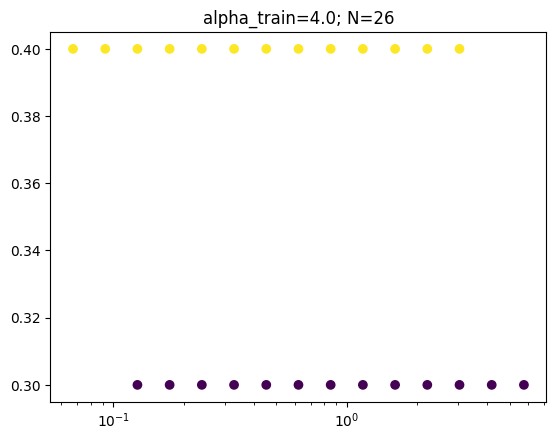

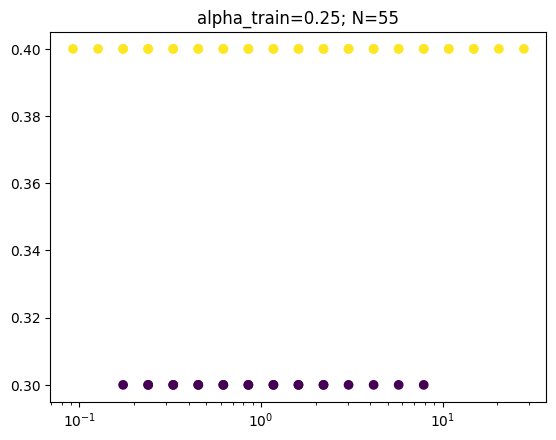

In [81]:
for i in df['alpha_train'].unique():
    _tmp = df[df['alpha_train'] == i]
    
    plt.figure()
    plt.scatter(_tmp['alpha_test'], _tmp['C_y'], c=_tmp['C_y'])
    plt.title(f"alpha_train={i}; N={len(_tmp)}")
    plt.xscale('log')
    plt.show()

In [82]:
len(df)

537

In [83]:
len(_tmp)

55

# Exps..

In [ ]:
import numpy as np
from numpy.random import uniform

In [56]:
lower_lim = 1e-2
upper_lim = 1e2

In [141]:
x = np.float_power(10, np.arange(-2,2,1e-3))

# x = np.arange(-2,2,1e-2)
# x = [10**(_) for _ in x]

<Axes: ylabel='Count'>

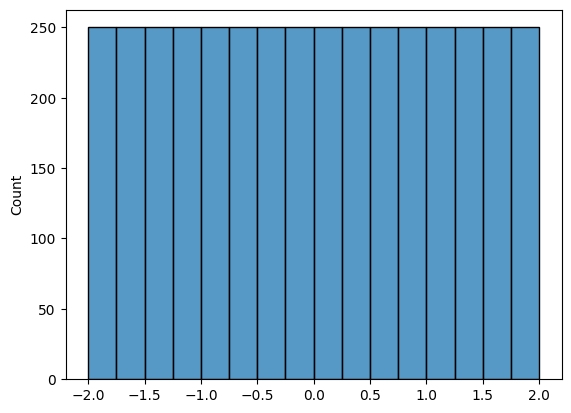

In [143]:
# plt.plot(np.log10(x))
sns.histplot(np.log10(x))


<Axes: ylabel='Count'>

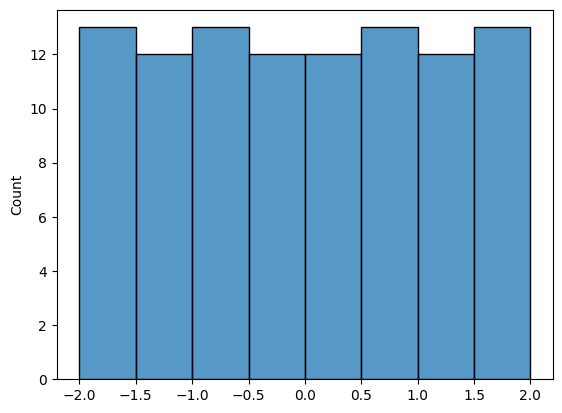

In [188]:
# plt.plot(np.log10(x))
sns.histplot(np.log10(alpha_test_ls))


<Axes: ylabel='Count'>

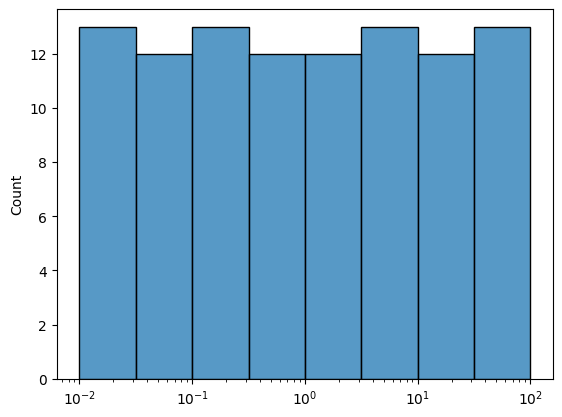

In [189]:
# plt.plot(np.log10(x))
sns.histplot(alpha_test_ls, log_scale=True)

# plt.xscale('log')

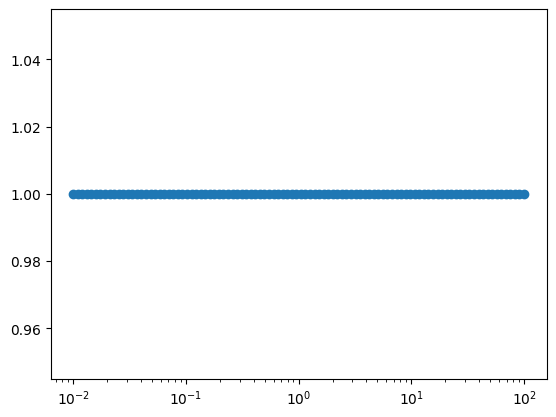

In [206]:
plt.scatter(alpha_test_ls, [1]*len(alpha_test_ls))
plt.xscale('log')

# No Py train == Py test

In [15]:
def confoundSplit(p_pos_train_z1, p_pos_train_z0, p_mix_z1, alpha_test, holdCy=True, p_pos_test_z1=None, p_pos_test_z0=None):
    """Calculate probability constraint given some priors"""

    assert 0 <= p_pos_train_z1 <= 1
    assert 0 <= p_pos_train_z0 <= 1
    assert 0 <= p_mix_z1 <= 1
    assert alpha_test >= 0

    C_z = p_mix_z1

    p_mix_z0 = 1 - p_mix_z1

    # C_y = p_train(y=1) = p_train(z=0) * p_train(y=1|z=0) + p_train(z=1) * p_train(y=1|z=1)
    # C_y = p_test(y=1) = p_test(z=0) * p_test(y=1|z=0) + p_test(z=1) * p_test(y=1|z=1)
    C_y = p_mix_z0 * p_pos_train_z0 + p_mix_z1 * p_pos_train_z1

    if holdCy:
        p_pos_test_z0 = C_y / (1 - (1 - alpha_test) * C_z)
        p_pos_test_z1 = alpha_test * p_pos_test_z0
        
        C_y_test = C_y
        
    else:
        assert 0 <= p_pos_test_z1 <= 1
        assert 0 <= p_pos_test_z0 <= 1
        
        alpha_test = p_pos_test_z1/p_pos_test_z0
        C_y_test = p_mix_z0 * p_pos_test_z0 + p_mix_z1 * p_pos_test_z1
        

    # alpha_test = p_pos_test_z1 / p_pos_test_z0
    alpha_train = p_pos_train_z1 / p_pos_train_z0

    ret = {
        "p_pos_train_z0": p_pos_train_z0,
        "p_pos_train_z1": p_pos_train_z1,
        "p_pos_train": C_y,
        "p_pos_test": C_y,
        "p_mix_z0": p_mix_z0,
        "p_mix_z1": p_mix_z1,
        "alpha_train": alpha_train,
        "alpha_test": alpha_test,
        "p_pos_test_z0": p_pos_test_z0,
        "p_pos_test_z1": p_pos_test_z1,
        "C_y": C_y,
        "C_z": C_z,
        "C_y_test":C_y_test,
    }
    
    
    return ret




def number_split(
    p_pos_train_z1,
    p_pos_train_z0,
    p_mix_z1,
    alpha_test,
    train_test_ratio=5,
    n_test=100,  # set the number for tests
    verbose=True,
    holdCy=True, p_pos_test_z1=None, p_pos_test_z0=None
):
    """Get required number of samples for each category"""
    assert isinstance(train_test_ratio, int)
    assert isinstance(n_test, int)

    mix_param_dict = confoundSplit(
            p_pos_train_z0=p_pos_train_z0,
            p_pos_train_z1=p_pos_train_z1,
            p_mix_z1=p_mix_z1,
            alpha_test=alpha_test,
            holdCy=holdCy,
            p_pos_test_z1=p_pos_test_z1,
            p_pos_test_z0=p_pos_test_z0
        )
        

    if all(
        0 < mix_param_dict[key] < 1
        for key in mix_param_dict.keys()
        if key not in ["alpha_test", "alpha_train"]
    ):  # assert all probability between 0 and 1

        n_train = n_test * train_test_ratio

        n_z1_train = round(n_train * mix_param_dict["C_z"])
        n_z1_test = round(n_test * mix_param_dict["C_z"])

        n_z0_train = n_train - n_z1_train
        n_z0_test = n_test - n_z1_test

        n_z1_p_train = round(n_z1_train * mix_param_dict["p_pos_train_z1"])
        n_z0_p_train = round(n_z0_train * mix_param_dict["p_pos_train_z0"])

        n_z1_p_test = round(n_z1_test * mix_param_dict["p_pos_test_z1"])
        n_z0_p_test = round(n_z0_test * mix_param_dict["p_pos_test_z0"])

        n_z1_n_train = n_z1_train - n_z1_p_train
        n_z0_n_train = n_z0_train - n_z0_p_train

        n_z1_n_test = n_z1_test - n_z1_p_test
        n_z0_n_test = n_z0_test - n_z0_p_test

        ans = {
            "n_train": n_train,
            "n_test": n_test,
            "n_z0_pos_train": n_z0_p_train,
            "n_z0_neg_train": n_z0_n_train,
            "n_z0_pos_test": n_z0_p_test,
            "n_z0_neg_test": n_z0_n_test,
            "n_z1_pos_train": n_z1_p_train,
            "n_z1_neg_train": n_z1_n_train,
            "n_z1_pos_test": n_z1_p_test,
            "n_z1_neg_test": n_z1_n_test,
            "mix_param_dict": mix_param_dict,
        }

        if all(ans[key] > 0 for key in ans.keys() if key != "mix_param_dict"):

            return ans

        elif verbose:
            print(
                "Invalid sample numbers ",
                [(key, val) for key, val in ans.items() if key != "mix_param_dict"],
            )
            return None

    elif verbose:
        print(
            f"Invalid test set probability P(Y=1|Z=0):{mix_param_dict['p_pos_test_z0']}, P(Y=1|Z=1):{mix_param_dict['p_pos_test_z1']}"
        )

    return None



In [118]:
holdCy = False


## Hate Speech

df0 = df_dynGen
df1 = df_wsf
df_split_label = "label_binary"

p_pos_train_z0_ls = np.arange(0, 1, 0.1) # probability of training set examples drawn from site/domain z0 being positive
p_pos_train_z1_ls = np.arange(0, 1, 0.1) # probability of test set examples drawn from site/domain z1 being positive
p_mix_z1_ls     = np.arange(0.1, 1, 0.1) 
n_test = 1000



## SHAC

# df_split_label = "Drug"

# df0 = df_shac_uw
# df1 = df_shac_mimic
# p_pos_train_z0_ls = np.arange(0.1, 1, 0.1)
# p_pos_train_z1_ls = np.arange(0.1, 1, 0.1)
# # p_pos_train_z0_ls = [0.1, 0.4, 0.6]
# # p_pos_train_z1_ls = [0.1, 0.4, 0.6]
# p_pos_test_z0_ls = np.arange(0.1, 1, 0.1)
# # p_pos_test_z1_ls = np.arange(0.1, 1, 0.1)

# p_mix_z1_ls = np.arange(0, 1, 0.1)

# n_test = 200

##### Split

train_test_ratio = 4


# numvals = 21
# base = 1.1
# alpha_test_ls = np.power(base, np.arange(numvals)) / np.power(base, numvals // 2)
alpha_test_ls = np.float_power(10, np.linspace(start=-2, stop=2, num=50))

p_pos_test_z1_ls = [i*j for i,j in itertools.product(p_pos_test_z0_ls, alpha_test_ls) if i*j <=1]

valid_full_settings = []
for combination in itertools.product(
    p_pos_train_z0_ls, p_pos_train_z1_ls, p_mix_z1_ls, [1], p_pos_test_z0_ls, p_pos_test_z1_ls
):
    if combination[5]/combination[4] not in alpha_test_ls:
        continue
        
    if round(combination[1]/combination[0], 4) not in [1, 1.5, 0.6667, 2, 0.5, 3, 0.3333, 4, 0.25, 6, 0.1667]:
        continue
        
    number_setting = number_split(
        p_pos_train_z0=combination[0],
        p_pos_train_z1=combination[1],
        p_mix_z1=combination[2],
        alpha_test=combination[3],
        train_test_ratio=train_test_ratio,
        n_test=n_test,
        verbose=False,
        holdCy=holdCy,
        p_pos_test_z0=combination[4],
        p_pos_test_z1=combination[5],
    )

    
            
    if number_setting is not None:
        if np.all([number_setting[k] >= 10 for k in list(number_setting.keys())[:-1]]):
            valid_full_settings.append(number_setting)



In [119]:
tmp_df = [x['mix_param_dict'] for x in valid_full_settings]

tmp_df = pd.DataFrame(tmp_df)

# tmp_df['alpha_train'] = tmp_df['alpha_train'].round(4)
# tmp_df['C_y1'] = np.floor(tmp_df['C_y']*10)/10
# tmp_df['combination'] = valid_full_settings



In [127]:
tmp_df['combination'] = valid_full_settings

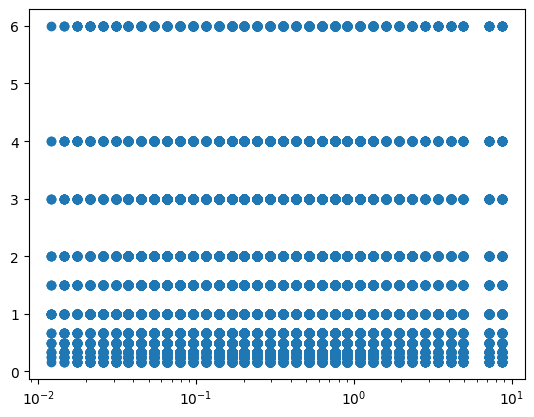

In [120]:
ax = plt.subplot()
ax=plt.scatter(x=tmp_df['alpha_test'], y=tmp_df['alpha_train'])
plt.xscale('log')


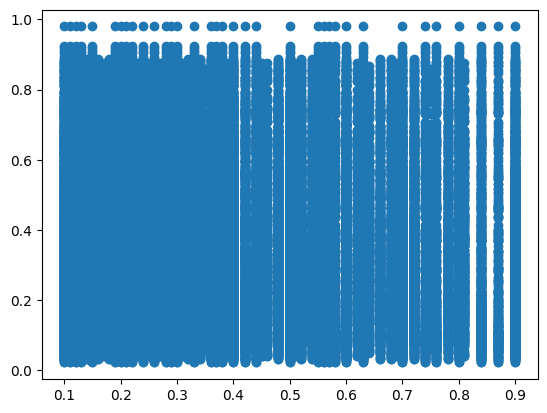

In [121]:
ax = plt.subplot()
ax=plt.scatter(x=tmp_df['C_y'], y=tmp_df['C_y_test'])


In [146]:
tmp_df['C_y_test_d1'] = np.floor(tmp_df['C_y_test']*10)/10
df_grp = tmp_df.groupby(["C_y_test"], as_index=False).size()

In [149]:
tmp_df = tmp_df.merge(df_grp, on='C_y_test', how='inner')

In [150]:
tmp_df

,p_pos_train_z0,p_pos_train_z1,p_pos_train,p_pos_test,p_mix_z0,p_mix_z1,alpha_train,alpha_test,p_pos_test_z0,p_pos_test_z1,C_y,C_z,C_y_test,combination,C_y_test_d1,size
0,0.1,0.1,0.10,0.10,0.9,0.1,1.000000,1.098541,0.1,0.109854,0.10,0.1,0.100985,"{'n_train': 4000, 'n_test': 1000, 'n_z0_pos_tr...",0.1,35
1,0.1,0.2,0.11,0.11,0.9,0.1,2.000000,1.098541,0.1,0.109854,0.11,0.1,0.100985,"{'n_train': 4000, 'n_test': 1000, 'n_z0_pos_tr...",0.1,35
2,0.1,0.3,0.12,0.12,0.9,0.1,3.000000,1.098541,0.1,0.109854,0.12,0.1,0.100985,"{'n_train': 4000, 'n_test': 1000, 'n_z0_pos_tr...",0.1,35
3,0.1,0.4,0.13,0.13,0.9,0.1,4.000000,1.098541,0.1,0.109854,0.13,0.1,0.100985,"{'n_train': 4000, 'n_test': 1000, 'n_z0_pos_tr...",0.1,35
4,0.1,0.6,0.15,0.15,0.9,0.1,6.000000,1.098541,0.1,0.109854,0.15,0.1,0.100985,"{'n_train': 4000, 'n_test': 1000, 'n_z0_pos_tr...",0.1,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48365,0.8,0.4,0.44,0.44,0.1,0.9,0.500000,1.098541,0.9,0.988687,0.44,0.9,0.979818,"{'n_train': 4000, 'n_test': 1000, 'n_z0_pos_tr...",0.9,35
48366,0.8,0.8,0.80,0.80,0.1,0.9,1.000000,1.098541,0.9,0.988687,0.80,0.9,0.979818,"{'n_train': 4000, 'n_test': 1000, 'n_z0_pos_tr...",0.9,35
48367,0.9,0.3,0.36,0.36,0.1,0.9,0.333333,1.098541,0.9,0.988687,0.36,0.9,0.979818,"{'n_train': 4000, 'n_test': 1000, 'n_z0_pos_tr...",0.9,35
48368,0.9,0.6,0.63,0.63,0.1,0.9,0.666667,1.098541,0.9,0.988687,0.63,0.9,0.979818,"{'n_train': 4000, 'n_test': 1000, 'n_z0_pos_tr...",0.9,35


In [155]:
tmp_df.sort_values(['C_y_test_d1', 'C_y_test','size'], ascending=False)

,p_pos_train_z0,p_pos_train_z1,p_pos_train,p_pos_test,p_mix_z0,p_mix_z1,alpha_train,alpha_test,p_pos_test_z0,p_pos_test_z1,C_y,C_z,C_y_test,combination,C_y_test_d1,size
48335,0.1,0.1,0.10,0.10,0.1,0.9,1.000000,1.098541,0.9,0.988687,0.10,0.9,0.979818,"{'n_train': 4000, 'n_test': 1000, 'n_z0_pos_tr...",0.9,35
48336,0.1,0.2,0.19,0.19,0.1,0.9,2.000000,1.098541,0.9,0.988687,0.19,0.9,0.979818,"{'n_train': 4000, 'n_test': 1000, 'n_z0_pos_tr...",0.9,35
48337,0.1,0.3,0.28,0.28,0.1,0.9,3.000000,1.098541,0.9,0.988687,0.28,0.9,0.979818,"{'n_train': 4000, 'n_test': 1000, 'n_z0_pos_tr...",0.9,35
48338,0.1,0.4,0.37,0.37,0.1,0.9,4.000000,1.098541,0.9,0.988687,0.37,0.9,0.979818,"{'n_train': 4000, 'n_test': 1000, 'n_z0_pos_tr...",0.9,35
48339,0.1,0.6,0.55,0.55,0.1,0.9,6.000000,1.098541,0.9,0.988687,0.55,0.9,0.979818,"{'n_train': 4000, 'n_test': 1000, 'n_z0_pos_tr...",0.9,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41750,0.8,0.4,0.44,0.44,0.1,0.9,0.500000,0.138950,0.1,0.013895,0.44,0.9,0.022505,"{'n_train': 4000, 'n_test': 1000, 'n_z0_pos_tr...",0.0,35
41751,0.8,0.8,0.80,0.80,0.1,0.9,1.000000,0.138950,0.1,0.013895,0.80,0.9,0.022505,"{'n_train': 4000, 'n_test': 1000, 'n_z0_pos_tr...",0.0,35
41752,0.9,0.3,0.36,0.36,0.1,0.9,0.333333,0.138950,0.1,0.013895,0.36,0.9,0.022505,"{'n_train': 4000, 'n_test': 1000, 'n_z0_pos_tr...",0.0,35
41753,0.9,0.6,0.63,0.63,0.1,0.9,0.666667,0.138950,0.1,0.013895,0.63,0.9,0.022505,"{'n_train': 4000, 'n_test': 1000, 'n_z0_pos_tr...",0.0,35


In [159]:
tmp = tmp_df.sort_values(['C_y_test_d1', 'C_y_test','size'], ascending=False).groupby('C_y_test_d1').head(1)

In [161]:
tmp_df = tmp_df[tmp_df['C_y_test'].isin(tmp['C_y_test'])]

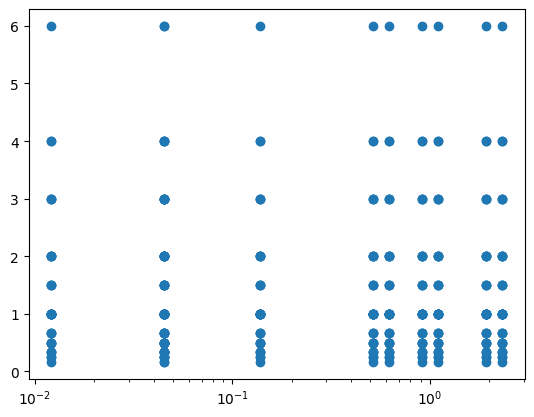

In [162]:
ax = plt.subplot()
ax=plt.scatter(x=tmp_df['alpha_test'], y=tmp_df['alpha_train'])
plt.xscale('log')


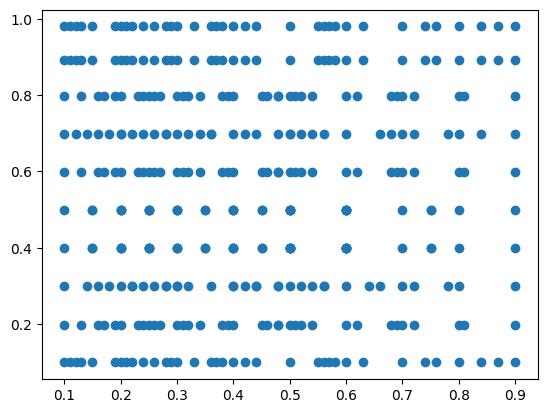

In [163]:
ax = plt.subplot()
ax=plt.scatter(x=tmp_df['C_y'], y=tmp_df['C_y_test'])


In [165]:
df_shac

,id,Drug,Alcohol,Tobacco,SubstanceAgg,set,location,text
0,3407,True,False,False,True,train,uw,Social History: Work: Unemployed Lives with m...
1,3313,False,True,False,True,train,uw,SOCIAL HISTORY: Living situation: Comfortabl...
2,3045,True,False,True,True,train,uw,HABITS: Tobacco Use: Approximately 20 pack-ye...
3,4399,False,True,True,True,train,uw,Social History: Immigrated from [LOCATION] in ...
4,3637,False,False,True,True,train,uw,HABITS: Tobacco Use: Formerly smoked 1-2 ciga...
...,...,...,...,...,...,...,...,...
4400,2884,True,True,False,True,test,mimic,Social History: lives w/ mother in [**Name2 (N...
4401,2728,False,False,True,True,test,mimic,Social History: lives with wife (recent nursin...
4402,2854,False,True,True,True,test,mimic,"Social History: quit smoking several yrs ago, ..."
4403,2726,False,False,False,False,test,mimic,"Social History: Denies Tob, EtOH, or Illicit d..."


In [168]:
z_category = ["uw", "mimic"]
domain_col = "location"

label = domain_col

# z_category.reverse()

label2id = {z: idx for idx, z in zip(range(len(z_category)), z_category)}
id2label = {idx: z for idx, z in zip(range(len(z_category)), z_category)}

df_shac["label_binary"] = df_shac.apply(lambda x: label2id[x[label]], axis=1)
df_shac["dfSource"] = df_shac[domain_col]

In [169]:
df_shac

,id,Drug,Alcohol,Tobacco,SubstanceAgg,set,location,text,label_binary,dfSource
0,3407,True,False,False,True,train,uw,Social History: Work: Unemployed Lives with m...,0,uw
1,3313,False,True,False,True,train,uw,SOCIAL HISTORY: Living situation: Comfortabl...,0,uw
2,3045,True,False,True,True,train,uw,HABITS: Tobacco Use: Approximately 20 pack-ye...,0,uw
3,4399,False,True,True,True,train,uw,Social History: Immigrated from [LOCATION] in ...,0,uw
4,3637,False,False,True,True,train,uw,HABITS: Tobacco Use: Formerly smoked 1-2 ciga...,0,uw
...,...,...,...,...,...,...,...,...,...,...
4400,2884,True,True,False,True,test,mimic,Social History: lives w/ mother in [**Name2 (N...,1,mimic
4401,2728,False,False,True,True,test,mimic,Social History: lives with wife (recent nursin...,1,mimic
4402,2854,False,True,True,True,test,mimic,"Social History: quit smoking several yrs ago, ...",1,mimic
4403,2726,False,False,False,False,test,mimic,"Social History: Denies Tob, EtOH, or Illicit d...",1,mimic


In [173]:
list(set(['k'])) + ['d']

['k', 'd']

In [2]:
import numpy as np
alpha_test_ls = np.float_power(10, np.linspace(start=-2, stop=2, num=40))


In [9]:
np.concatenate([alpha_test_ls,[1,0.2,5]])

array([1.00000000e-02, 1.26638017e-02, 1.60371874e-02, 2.03091762e-02,
       2.57191381e-02, 3.25702066e-02, 4.12462638e-02, 5.22334507e-02,
       6.61474064e-02, 8.37677640e-02, 1.06081836e-01, 1.34339933e-01,
       1.70125428e-01, 2.15443469e-01, 2.72833338e-01, 3.45510729e-01,
       4.37547938e-01, 5.54102033e-01, 7.01703829e-01, 8.88623816e-01,
       1.12533558e+00, 1.42510267e+00, 1.80472177e+00, 2.28546386e+00,
       2.89426612e+00, 3.66524124e+00, 4.64158883e+00, 5.87801607e+00,
       7.44380301e+00, 9.42668455e+00, 1.19377664e+01, 1.51177507e+01,
       1.91448198e+01, 2.42446202e+01, 3.07029063e+01, 3.88815518e+01,
       4.92388263e+01, 6.23550734e+01, 7.89652287e+01, 1.00000000e+02,
       1.00000000e+00, 2.00000000e-01, 5.00000000e+00])